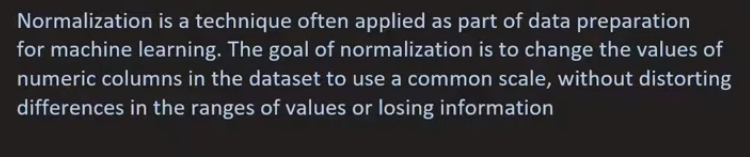

# 1. MINMAX NORMALIZATION

# FORMULAE

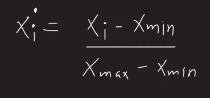

# RANGE

- FROM 0 TO 1
- WHEN Xi is min then zero
- when Xi is max then 1

In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

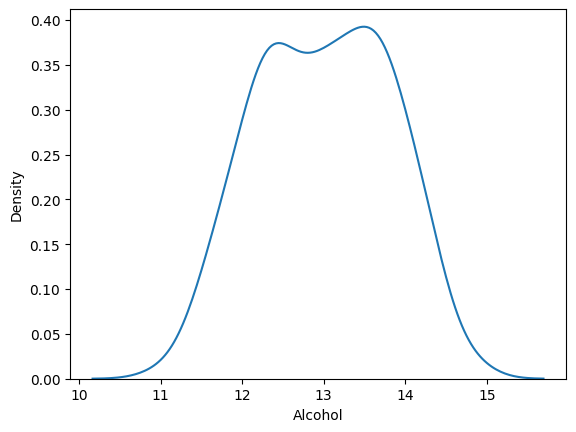

In [6]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

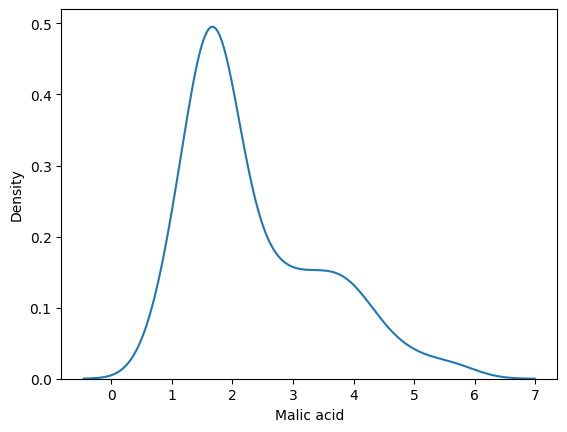

In [7]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

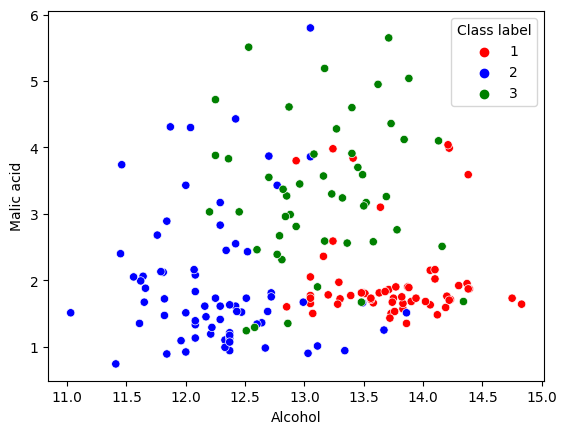

In [14]:
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],hue=df['Class label'],palette=color_dict)

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1),
                                                    df['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [17]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [18]:
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [19]:
np.round(X_train_scaled.describe(), 1)
# min and max values range from o to 1

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


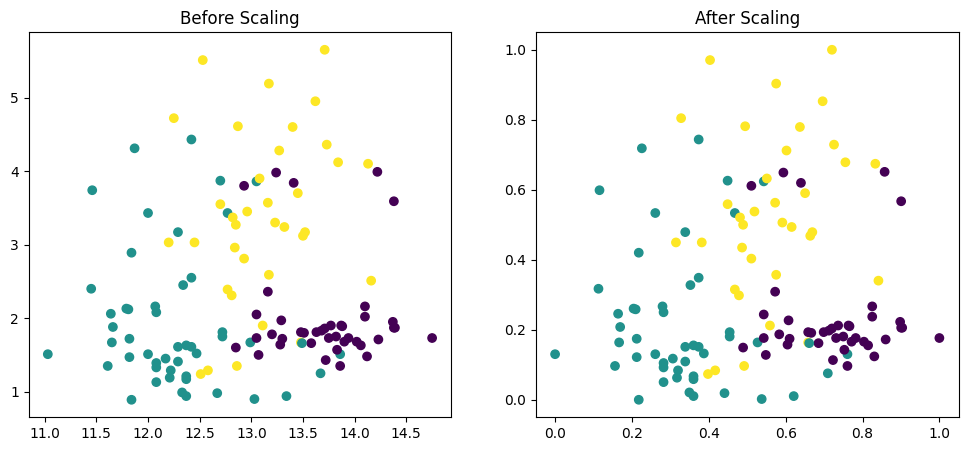

In [21]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

# here no mean centring is done but data is kind of squished between 0 to 1 range

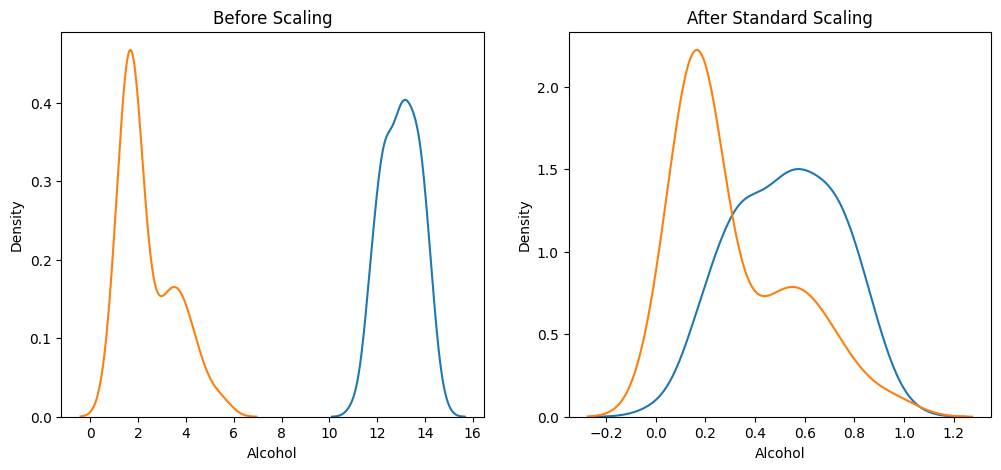

In [22]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

**HERE BELOW DISTRIBUTIONS LOOK SAME BUT CAN BE DIFFERENT**

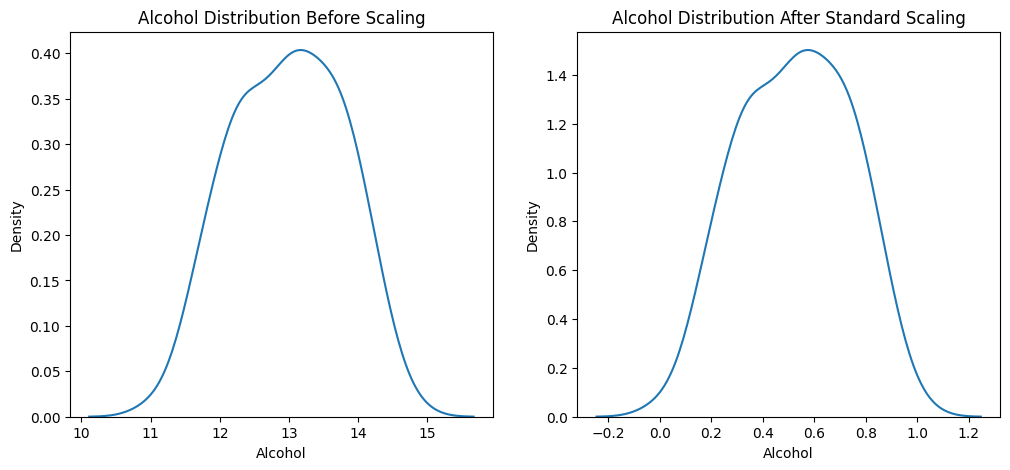

In [23]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

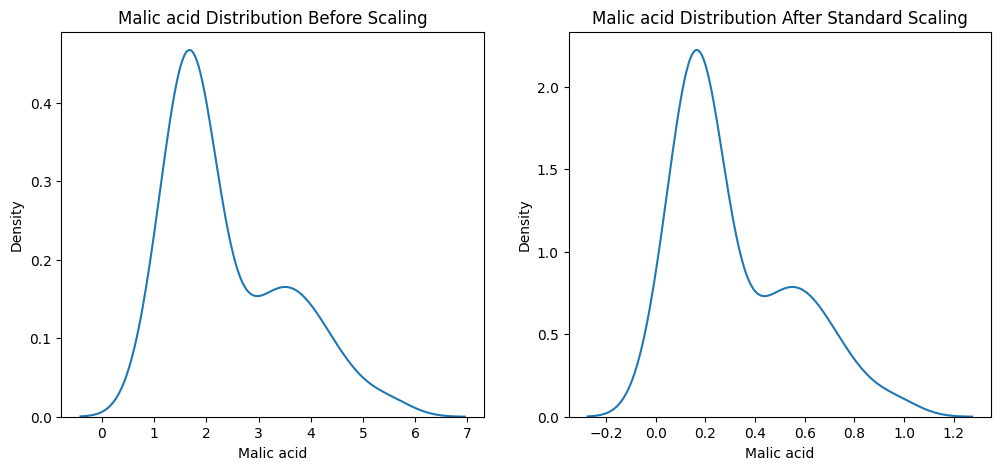

In [24]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()



---



---



---



# 2. MEAN NORMALIZATION

# FORMULAR
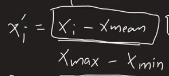

- HERE MEAN CENTRING IS DONE LIKE STANDARDIZATION
- BUT IN TERMS OF RANGE NOT STD
- RANGE IS FROM -1 TO 1
- VERY RARELY USED ONLY IN ALGORITHUMS WHERE CENTRED DATA IS REQUIRED BUT EVEN THER STANDARDIZATION CAN BE USED
- **NO IMPLEMENTATION IN SKLEARN**



---


---




#3.  MaxAbsScaling

# FORMULAR

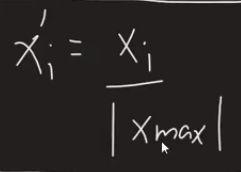


In [ ]:
# from sklearn.preprocessing import MaxAbsScaler

- MOSTLY USED IN **SPARSE DATASET**(WHERE WE HAVE A LARGE NO OF ZEROS)



---



---



---



# 4. RobustScaling

# FORMULAE

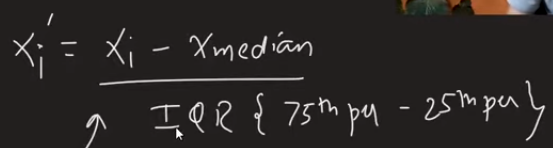

In [ ]:
# from sklearn.preprocessing import RobustScaler

- **IT IS ROBUST TO OUTLIERS**



---

---



---



---





# NORMALIZATION VS STANDARDIZATION

- **FIRST**  ...................................................... IS FEATURE SCALING REQUIRED?
- MIN MAX NORMALIZATION...................WHEN WE ALREADY KNOW THE MIN AND MAX VALUE OF DATA (I.E IN IMAGE PROCESSING IN CNN)
- STANDARDIZATION ...............................MOSTLY IT WORKS BETTER ( WHEN THERE IS NOT AUTHENTIC REASON TO USE OTHER SCALING METHODS , GO FOR THIS!)
- OUTLIERS................................................ ROBUST SCALING
- SPARSE DATA.........................................MaxAbsScaling